# Análise Exploratória de Dados — Bike Sharing

Este notebook apresenta uma análise exploratória dos dados de aluguel de bicicletas, com o objetivo de compreender a distribuição, o comportamento e os principais padrões presentes nos dados.

Ao longo da análise, serão investigadas características temporais, sazonais, climáticas e relacionadas ao perfil dos usuários, buscando identificar padrões relevantes na demanda por aluguéis.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_PATH = '../data/'
file_name = 'bike_sharing_silver.csv'

df = pd.read_csv(DATA_PATH+file_name, sep=',')
df_eda = df.copy()

df.head(1)

,instant,season,year,month,hour,holiday,weekday,working_day,weather_sit,temp,feeling_temp,hum,wind_speed,casual,registered,datetime,cnt
0,1,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,2011-01-01 00:00:00,16


In [2]:
TARGET_COLUMN = 'cnt'
NUMERIC_COLUMNS = ['temp', 'feeling_temp', 'hum', 'wind_speed', 'casual', 'registered']
CATEGORICAL_COLUMNS = ['holiday', 'weekday', 'working_day', 'weather_sit']
DATETIME_COLUMN = 'datetime'

# Variável Target

### Agrupamento dos aluguéis por mês e ano

Nesta etapa, os dados são agrupados por mês e ano, permitindo analisar a quantidade de aluguéis em cada período.

In [3]:
# Converte a coluna datetime para o tipo datetime
df[DATETIME_COLUMN] = pd.to_datetime(df[DATETIME_COLUMN])

# Agrupa os registros por ano e mês e soma a quantidade de aluguéis
df_monthly = (df.groupby(df[DATETIME_COLUMN].dt.to_period('M')).agg(
        cnt=(TARGET_COLUMN, 'sum'),
        casual=('casual', 'sum'),
        registered=('registered', 'sum'),
        year=('year', 'first'),
        
).reset_index())

# Converte o período novamente para datetime
df_monthly[DATETIME_COLUMN] = df_monthly[DATETIME_COLUMN].dt.to_timestamp()

### Meses com a maior média de aluguéis

Nesta etapa, analisamos a média de aluguéis para identificar quais meses apresentam os maiores valores médios.

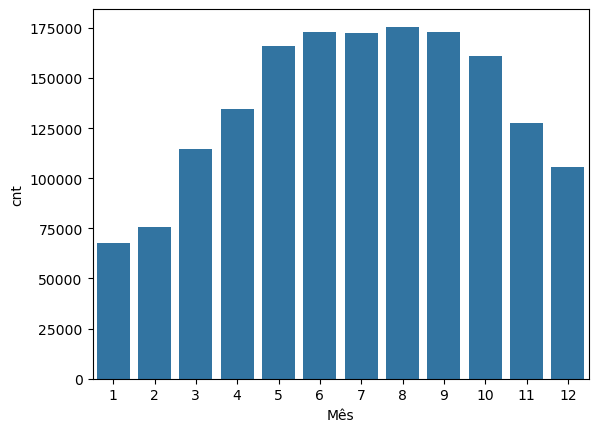

In [4]:
df_month = df_monthly.groupby(df_monthly[DATETIME_COLUMN].dt.month).agg(cnt=(TARGET_COLUMN, 'mean')).reset_index()

sns.barplot(data=df_month,x=DATETIME_COLUMN, y=TARGET_COLUMN)

# Define os rótulos dos eixos
plt.xlabel('Mês')

# Exibe o gráfico
plt.show()

### Função de agregação

In [5]:

def agg_daily_mean(column):
    
    aggregation = {
        'cnt': (TARGET_COLUMN, 'sum'),
        column: (column, 'first')
    }
    
    # Agrupa os dados por dia e aplica as agregações
    df_daily = (
        df.groupby(df[DATETIME_COLUMN].dt.to_period('D'))
        .agg(**aggregation) # ** desempacota o dicionario aggregation
        .reset_index()
    )

    # Calcula a média diária da variável target por categoria
    df_daily_mean = (
        df_daily.groupby(df_daily[column])
        .agg(cnt=(TARGET_COLUMN, 'mean'))
        .reset_index()
    )
    
    return df_daily_mean

### Dias da semana com a maior média de aluguéis

Nesta etapa, analisamos a média de aluguéis para cada dia da semana. A variável `weekday` utiliza os seguintes valores:

- **0:** Domingo
- **1:** Segunda-feira
- **2:** Terça-feira
- **3:** Quarta-feira
- **4:** Quinta-feira
- **5:** Sexta-feira
- **6:** Sábado

A partir dessa classificação, podemos comparar a média de aluguéis entre os diferentes dias da semana.

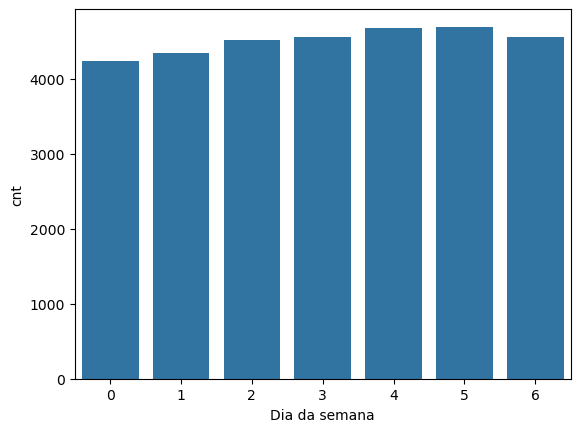

In [6]:
df_week_mean = agg_daily_mean('weekday')

sns.barplot(data=df_week_mean,x='weekday', y=TARGET_COLUMN)

# Define os rótulos dos eixos
plt.xlabel('Dia da semana')

# Exibe o gráfico
plt.show()

### Comparação da média de aluguéis em dias úteis

Nesta etapa, comparamos a média de aluguéis entre dias úteis e não úteis. A variável `working_day` utiliza os seguintes valores:

- **0:** Não é dia útil
- **1:** É dia útil

Essa comparação permite avaliar possíveis diferenças na demanda entre esses dois tipos de dia.

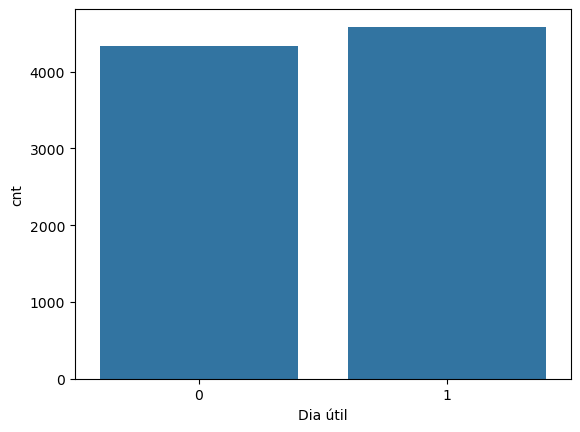

In [7]:
df_working_day = agg_daily_mean('working_day')

# Define os rótulos dos eixos
plt.xlabel('Dia útil')
sns.barplot(data=df_working_day,x='working_day', y=TARGET_COLUMN)
plt.show()

### Comparação da média de aluguéis em feriados

Nesta etapa, comparamos a média de aluguéis entre os dias considerados feriados e os demais dias. A variável `holiday` utiliza os seguintes valores:

- **0:** Não é feriado
- **1:** É feriado

Essa comparação permite avaliar possíveis diferenças na demanda entre feriados e não feriados.

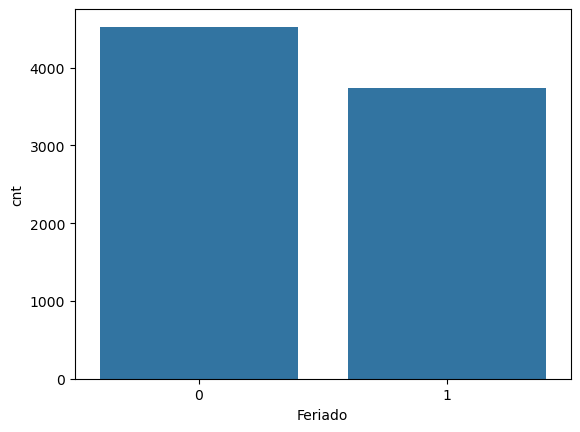

In [8]:
df_holiday = agg_daily_mean('holiday')

# Define os rótulos dos eixos
plt.xlabel('Feriado')
sns.barplot(data=df_holiday,x='holiday', y=TARGET_COLUMN)
plt.show()

### Comparação da média de aluguéis de acordo com as estações do ano

Nesta etapa, comparamos a média de aluguéis entre as estações do ano. A variável `season` utiliza os seguintes valores:

- **1:** Inverno
- **2:** Primavera
- **3:** Verão
- **4:** Outono

Essa comparação permite avaliar possíveis diferenças na demanda entre as diferentes estações do ano.

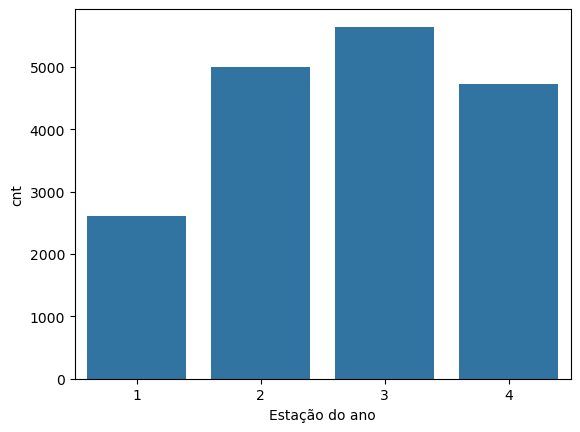

In [9]:
df_season = agg_daily_mean('season')

# Define os rótulos dos eixos
plt.xlabel('Estação do ano')
sns.barplot(data=df_season,x='season', y=TARGET_COLUMN)
plt.show()

### Comparação da média de aluguéis de acordo com as condições climáticas

Nesta etapa, comparamos a média de aluguéis entre as diferentes condições climáticas. A variável `weather_sit` utiliza os seguintes valores:

- **1:** Céu limpo, poucas nuvens ou parcialmente nublado
- **2:** Neblina ou nublado
- **3:** Neve fraca ou chuva fraca
- **4:** Chuva forte, granizo, tempestade ou neve com neblina

Essa comparação permite avaliar possíveis variações na demanda de acordo com as condições climáticas.

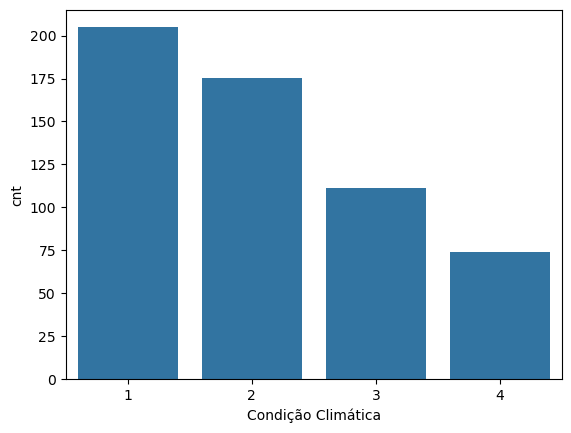

In [10]:
df_weather_sit = df.groupby(df['weather_sit']).agg(cnt=(TARGET_COLUMN, 'mean')).reset_index()

# Define os rótulos dos eixos
plt.xlabel('Condição Climática')
sns.barplot(data=df_weather_sit,x='weather_sit', y=TARGET_COLUMN)
plt.show()

### Verificação do horário com mais aluguéis

Nesta etapa, analisamos a média de aluguéis para cada horário do dia. A variável `hr` representa a hora do dia e possui valores de **0 a 23**.

A comparação entre os horários permite identificar quais períodos apresentam maior demanda por aluguéis.

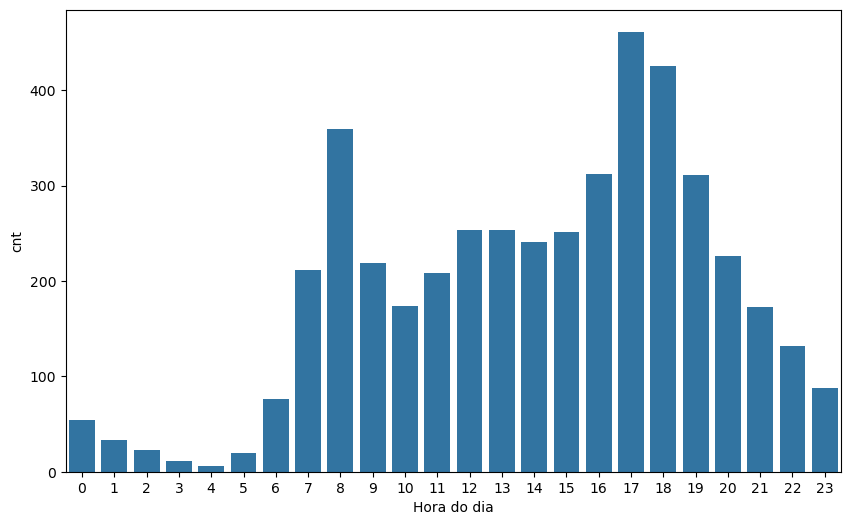

In [11]:
df_hour = df.groupby(df['hour']).agg(cnt=(TARGET_COLUMN, 'mean')).reset_index()

plt.figure(figsize=(10, 6))
plt.xlabel('Hora do dia')
sns.barplot(data=df_hour,x='hour', y=TARGET_COLUMN)
plt.show()

# Análise em relação ao tempo

### Comparação da quantidade de aluguéis por tipo de cliente ao longo do tempo

Nesta etapa, comparamos a quantidade total de aluguéis com a quantidade de aluguéis realizada por clientes registrados e não registrados ao longo do tempo. As variáveis utilizadas são:

- `cnt`: quantidade total de aluguéis
- `registered`: quantidade de aluguéis realizados por clientes registrados
- `casual`: quantidade de aluguéis realizados por clientes não registrados

Essa comparação permite analisar a participação de cada tipo de cliente na quantidade total de aluguéis ao longo do período analisado.

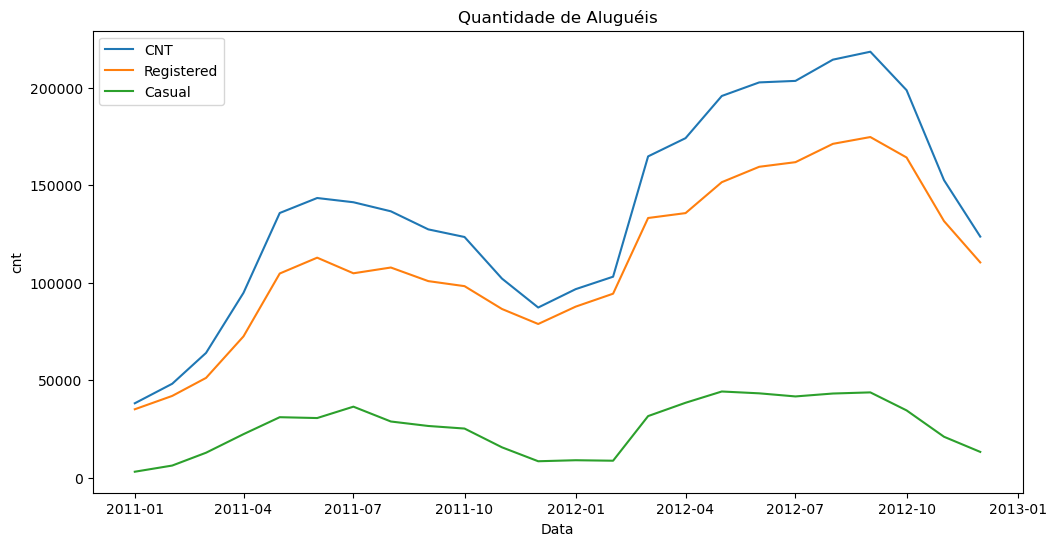

In [12]:
plt.figure(figsize=(12, 6))

# Cria o gráfico de linha utilizando datetime no eixo X
sns.lineplot(
    data=df_monthly,
    x=DATETIME_COLUMN,
    y=TARGET_COLUMN,
    label='CNT'
)

# Plota usuários registrados
sns.lineplot(
    data=df_monthly,
    x=DATETIME_COLUMN,
    y='registered',
    label='Registered'
)

# Plota usuários registrados
sns.lineplot(
    data=df_monthly,
    x=DATETIME_COLUMN,
    y='casual',
    label='Casual'
)

# Define os rótulos dos eixos
plt.title('Quantidade de Aluguéis')
plt.xlabel('Data')

# Exibe o gráfico
plt.show()

### Aumento da demanda de 2011 para 2012

Ao comparar a quantidade total de aluguéis entre 2011 e 2012, observamos um aumento de 64,88% na demanda.

In [13]:
# Separação do dataset entre 2011 e 2012
df_2011 = df[df['year'] == 0]
df_2012 = df[df['year'] == 1]

sum_cnt_2011 = df_2011[TARGET_COLUMN].sum()
sum_cnt_2012 = df_2012[TARGET_COLUMN].sum()
cnt_increase_percent = sum_cnt_2012 * 100 / sum_cnt_2011 - 100
print(f'Aumento da demanda: {cnt_increase_percent:.2f}%')


Aumento da demanda: 64.88%


### Comportamento dos aluguéis em 2011

Nesta etapa, analisamos o comportamento da quantidade de aluguéis ao longo de 2011. Foram observados 12 períodos, com uma média de 103.591,92 aluguéis.

A quantidade mínima registrada foi de 38.189 aluguéis, enquanto a máxima foi de 143.512. A mediana foi de 112.839 aluguéis, indicando que metade dos períodos apresentou valores abaixo desse nível e a outra metade acima.

O desvio padrão de 37.377,93 indica uma variação considerável na quantidade de aluguéis entre os períodos analisados.

In [14]:
df_2011.describe()[TARGET_COLUMN].round(2)

count    8645.00
mean      143.79
min         1.00
25%        31.00
50%       109.00
75%       211.00
max       651.00
std       133.80
Name: cnt, dtype: float64

### Comportamento dos aluguéis em 2012

Nesta etapa, analisamos o comportamento da quantidade de aluguéis ao longo de 2012. Foram observados 12 períodos, com uma média de 170.798,00 aluguéis.

A quantidade mínima registrada foi de 96.744 aluguéis, enquanto a máxima foi de 218.573. A mediana foi de 185.044,50 aluguéis, indicando que metade dos períodos apresentou valores abaixo desse nível e a outra metade acima.

O desvio padrão de 43.026,93 indica uma variação considerável na quantidade de aluguéis entre os períodos analisados.

In [15]:
df_2012.describe()[TARGET_COLUMN].round(2)

count    8734.00
mean      234.67
min         1.00
25%        53.00
50%       191.00
75%       347.00
max       977.00
std       208.91
Name: cnt, dtype: float64

### Comparação mensal entre 2011 e 2012

Nesta etapa, comparamos a quantidade de aluguéis de cada mês de 2011 com o mesmo mês de 2012. A análise permite observar como a demanda evoluiu entre os dois anos para cada período do ano.

Foi identificado um aumento mais acentuado em setembro de 2012, comportamento que não foi observado no mesmo mês de 2011.

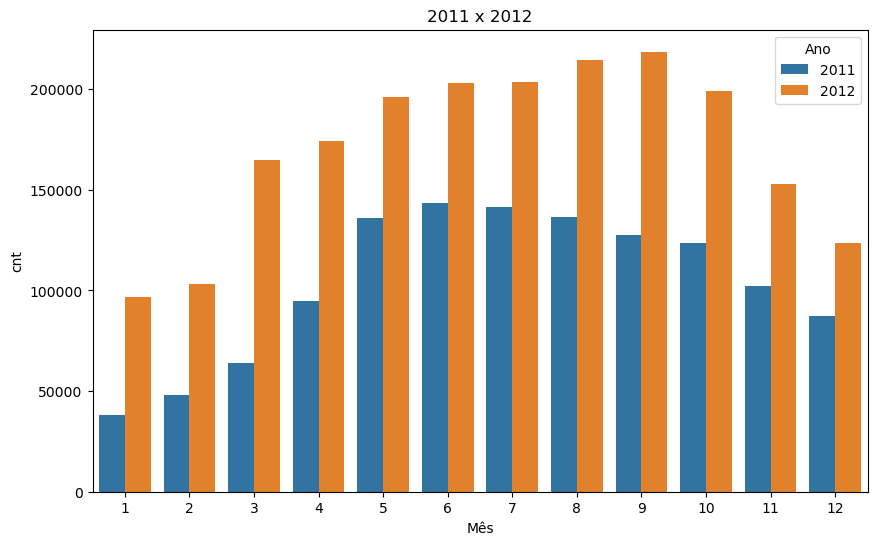

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_monthly, x=df_monthly[DATETIME_COLUMN].dt.month, y=TARGET_COLUMN, hue='year')
plt.title('2011 x 2012')
plt.xlabel('Mês')

handles, _ = plt.gca().get_legend_handles_labels()

# Altera a legenda do gráfico
plt.legend(
    handles=handles,
    title='Ano',
    labels=['2011', '2012']
)

plt.show()

# Sazonalidade

## Estação do ano

Identificamos um comportamento que se repete nos dois anos analisados: há um maior número de aluguéis durante a estação 3 (verão) e um menor número de aluguéis durante a estação 1 (inverno).

In [17]:
df_saz_season_2011 = df_2011.groupby(df_2011['season']).agg(cnt=(TARGET_COLUMN, 'sum'), year=('year', 'first'), ).reset_index()
df_saz_season_2012 = df_2012.groupby(df_2012['season']).agg(cnt=(TARGET_COLUMN, 'sum'), year=('year', 'first')).reset_index()
df_saz_season = pd.concat([df_saz_season_2011, df_saz_season_2012], axis=0)

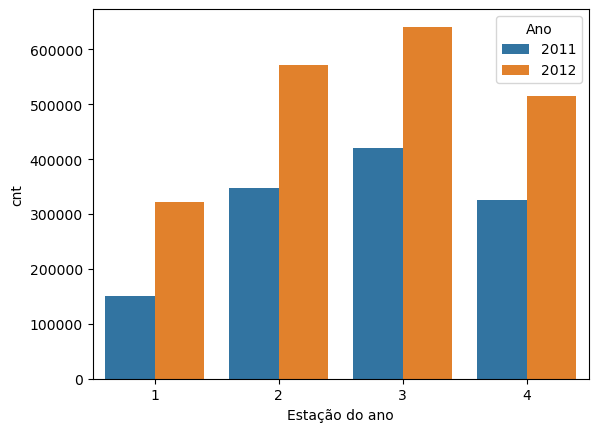

In [18]:
sns.barplot(data=df_saz_season, x='season', y=TARGET_COLUMN, hue='year')

plt.xlabel('Estação do ano')

handles, _ = plt.gca().get_legend_handles_labels()

# Altera a legenda do gráfico
plt.legend(
    handles=handles,
    title='Ano',
    labels=['2011', '2012']
)

plt.show()


### Agrupa o dataset em uma granularidade diária

In [19]:
aggregation = {
    'cnt': (TARGET_COLUMN, 'sum'),
    'season': ('season', 'first'),
    'year': ('year', 'first')
}
    
df_daily = (
    df.groupby(df[DATETIME_COLUMN].dt.to_period('D'))
    .agg(**aggregation) # ** desempacota o dicionario aggregation
    .reset_index()
)

# Converte a coluna datetime para timestamp
df_daily[DATETIME_COLUMN] = df_daily[DATETIME_COLUMN].dt.to_timestamp()

# Cria uma coluna onde cada linha representa o tempo que passou desde a primeira data
df_daily['time'] = (df_daily[DATETIME_COLUMN] - df_daily[DATETIME_COLUMN].min()).dt.days

df_daily.head(1)

,datetime,cnt,season,year,time
0,2011-01-01,985,1,0,0


### Verificação da consistência do padrão sazonal

Foi utilizado um modelo de regressão com efeitos de estação, ano e interação entre essas variáveis, utilizando erros-padrão robustos à autocorrelação (HAC). O efeito das estações foi estatisticamente significativo (p < 0,05), indicando diferenças na demanda entre os períodos sazonais.

As interações entre estação e ano não foram significativas (p > 0,05), indicando que não há evidência estatística de mudança no comportamento das estações entre 2011 e 2012. Esse resultado é consistente com o padrão observado nos gráficos, sugerindo que a sazonalidade da demanda se mantém entre os dois anos.

Apesar disso, a autocorrelação `Durbin-Watson: 0.948` residual observada indica que os resultados devem ser interpretados como evidência de consistência do padrão sazonal, e não como uma confirmação definitiva de sazonalidade na série temporal. Isso ocorre porque a autocorrelação indica que as observações ao longo do tempo não são completamente independentes, o que pode afetar a precisão da inferência estatística e dos p-valores, mesmo com o uso de erros-padrão robustos (HAC).

In [20]:
import statsmodels.formula.api as smf

model = smf.ols(
    'cnt ~ time + C(season) * C(year)',
    data=df_daily
).fit(
    cov_type='HAC',
    cov_kwds={'maxlags': 30}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     79.33
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           1.07e-93
Time:                        17:51:40   Log-Likelihood:                -6160.3
No. Observations:                 731   AIC:                         1.234e+04
Df Residuals:                     722   BIC:                         1.238e+04
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

## Sazonalidade Mensal
As variáveis year e month são extraídas da coluna de data. Year identifica o ano da observação, enquanto month representa o mês, permitindo avaliar os efeitos sazonais ao longo do ano.

O modelo especificado é:

cnt ~ time + C(month) * C(year)

Nesse modelo:

cnt é a variável dependente;
time representa a evolução temporal;
C(month) trata o mês como uma variável categórica, permitindo estimar um efeito específico para cada mês;
C(year) representa o efeito associado a cada ano;
C(month) * C(year) inclui os efeitos de mês, ano e a interação entre eles.

A interação entre mês e ano permite verificar se o comportamento mensal varia entre os anos analisados.

In [21]:
import statsmodels.formula.api as smf

# Cria as variáveis de ano e mês
df_daily['year'] = df_daily[DATETIME_COLUMN].dt.year
df_daily['month'] = df_daily[DATETIME_COLUMN].dt.month

model = smf.ols(
    'cnt ~ time + C(month) * C(year)',
    data=df_daily
).fit(
    cov_type='HAC',
    cov_kwds={'maxlags': 30}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.727
Method:                 Least Squares   F-statistic:                     843.0
Date:                Tue, 08 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:51:40   Log-Likelihood:                -6083.2
No. Observations:                 731   AIC:                         1.222e+04
Df Residuals:                     706   BIC:                         1.233e+04
Df Model:                          24                                         
Covariance Type:                  HAC                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

### Testes de Wald

O Teste de Wald verifica se uma ou mais variáveis possuem efeito estatisticamente significativo no modelo.
Ele testa se os coeficientes são estatisticamente diferentes de zero.
Quando o p-valor < 0,05, rejeitamos a hipótese de que não há efeito significativo.

Foram realizados dois testes de Wald para avaliar a sazonalidade e sua estabilidade entre os anos analisados.

O teste para `C(month)` apresentou `chi2 = 1988,30` e `p < 0,001`. Rejeitamos a hipótese nula de ausência de sazonalidade mensal, indicando evidência estatística de que o comportamento de `cnt` varia de acordo com o mês.

O teste para `C(month):C(year)` apresentou `chi2 = 81,07` e `p < 0,001`. Rejeitamos a hipótese nula de que o comportamento sazonal é estatisticamente igual entre 2011 e 2012, indicando que o padrão sazonal de `cnt` se modificou entre os anos analisados.

Portanto, os resultados indicam a presença de sazonalidade mensal e evidenciam que sua intensidade ou comportamento varia entre 2011 e 2012.

In [22]:
wald_test = model.wald_test(
    'C(month)[T.2] = 0, '
    'C(month)[T.3] = 0, '
    'C(month)[T.4] = 0, '
    'C(month)[T.5] = 0, '
    'C(month)[T.6] = 0, '
    'C(month)[T.7] = 0, '
    'C(month)[T.8] = 0, '
    'C(month)[T.9] = 0, '
    'C(month)[T.10] = 0, '
    'C(month)[T.11] = 0, '
    'C(month)[T.12] = 0'
)

wald_interaction = model.wald_test(
    'C(month)[T.2]:C(year)[T.2012] = 0, '
    'C(month)[T.3]:C(year)[T.2012] = 0, '
    'C(month)[T.4]:C(year)[T.2012] = 0, '
    'C(month)[T.5]:C(year)[T.2012] = 0, '
    'C(month)[T.6]:C(year)[T.2012] = 0, '
    'C(month)[T.7]:C(year)[T.2012] = 0, '
    'C(month)[T.8]:C(year)[T.2012] = 0, '
    'C(month)[T.9]:C(year)[T.2012] = 0, '
    'C(month)[T.10]:C(year)[T.2012] = 0, '
    'C(month)[T.11]:C(year)[T.2012] = 0, '
    'C(month)[T.12]:C(year)[T.2012] = 0'
)

print(wald_test)
print(wald_interaction)

<Wald test (chi2): statistic=[[1988.29707391]], p-value=0.0, df_denom=11>
<Wald test (chi2): statistic=[[81.07101628]], p-value=9.15680457753114e-13, df_denom=11>


D:\programas\anaconda\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
